# CatBoost on the undersampled data + post-evaluation rules (final submissions)

Trains a GPU CatBoost classifier on `train_sampled_data.csv`, predicts the test logs, then overrides predictions with rules mined from the full training set (non-attack referers/upstreams, HEAD requests, safe users, status > 404), merges an earlier non-attack prediction file and applies a Reconnaissance probability threshold. Produces submissions 1 to 5.

In [ ]:
DATA_DIR = "../data"
SUBMISSION_DIR = "../data/submissions"

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score

import catboost as cb
import lightgbm as lgb
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras import backend as K

## Load Data

In [197]:
ori_train_df = pd.read_csv(f"{DATA_DIR}/train_sampled_data.csv")
ori_train_df.head()

,Unnamed: 0,id,timestamp,remote_addr,remote_user,hostname,time_local,request,status,body_bytes_sent,...,upstream_response_time,upstream_addr,upstream_status,connection,connection_requests,data.srcip,agent.ip,rule.mitre.tactic,hour,pairwise
0,0,38,2023-08-29 17:05:43.445,66.96.233.60,-,vm-director-nginx,30/Aug/2023:00:05:42 +0700,POST /lib/ajax/service.php?sesskey=FyapD11LyJ&...,200,98,...,0.03,10.45.184.157:32401,200,688312591,181,66.96.233.60,192.168.1.99,"[""Impact""]",17,0.126820
1,1,54,2023-08-29 17:08:23.939,118.99.125.4,-,vm-director-nginx,30/Aug/2023:00:08:23 +0700,POST /lib/ajax/service.php?sesskey=QY0HDC3szQ&...,200,1169,...,0.068,10.45.184.143:32401,200,688315946,158,118.99.125.4,192.168.1.99,"[""Impact""]",17,0.091207
2,2,98,2023-08-29 17:16:56.322,125.166.1.20,-,vm-director-nginx,30/Aug/2023:00:16:54 +0700,POST /lib/ajax/service.php?sesskey=9dbAEW9y6f&...,200,27,...,0.088,10.45.184.157:32401,200,688328194,209,125.166.1.20,192.168.1.99,"[""Impact""]",17,0.290300
3,3,99,2023-08-29 17:17:14.250,103.171.147.123,-,vm-director-nginx,30/Aug/2023:00:17:13 +0700,POST /lib/ajax/service.php?sesskey=nscrep2nd3&...,200,27,...,0.098,10.45.184.157:32401,200,688330190,90,103.171.147.123,192.168.1.99,"[""Impact""]",17,0.328679
4,4,187,2023-08-29 17:22:58.771,180.248.17.197,-,vm-director-nginx,30/Aug/2023:00:22:56 +0700,POST /lib/ajax/service.php?sesskey=ezddPBRNs5&...,200,6712,...,0.104,10.45.184.142:32401,200,688336653,219,180.248.17.197,192.168.1.99,"[""Impact""]",17,0.077081


In [198]:
ori_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4758 entries, 0 to 4757
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              4758 non-null   int64  
 1   id                      4758 non-null   int64  
 2   timestamp               4758 non-null   object 
 3   remote_addr             4758 non-null   object 
 4   remote_user             4758 non-null   object 
 5   hostname                4758 non-null   object 
 6   time_local              4758 non-null   object 
 7   request                 4758 non-null   object 
 8   status                  4758 non-null   int64  
 9   body_bytes_sent         4758 non-null   int64  
 10  http_referer            4758 non-null   object 
 11  http_user_agent         4758 non-null   object 
 12  http_x_forwarded_for    4758 non-null   object 
 13  time_iso8601            4758 non-null   object 
 14  request_method          4758 non-null   

## Feature Engineering

In [199]:
ori_train_df.upstream_connect_time.value_counts()

0           2525
0.001       2144
0.002         49
0.005          7
0.004          6
0.003          5
0.008          4
-, 0.000       3
0.006          2
0.169          1
0.024          1
0.489          1
0.068          1
0.265          1
0.007          1
0.118          1
0.029          1
0.126          1
0.061          1
0.046          1
0.01           1
0.012          1
Name: upstream_connect_time, dtype: int64

In [200]:
ori_train_df.upstream_response_time.value_counts()

0.002    1339
0.001     817
0.003     448
0          98
0.004      48
         ... 
0.199       1
0.587       1
0.286       1
0.893       1
0.674       1
Name: upstream_response_time, Length: 601, dtype: int64

In [325]:
def clean_upstream_connect_time(x):
    x = x.split(', ')
    for i in range(len(x)):
        try:
            x[i] = float(x[i])
        except ValueError:
            x[i] = 0
    return np.max(x)

def extract_domain_from_url(url):
    pattern = r'^(?:https?:\/\/)?(?:[^@\/\n]+@)?(?:www\.)?([^:\/\n]+)'
    match = re.search(pattern, url)

    if match:
        domain = match.group(1)
        return domain
    else:
        return None
    
def group_http_referer(x):
    x = extract_domain_from_url(x)
    if "notrealdomain" in x:
        return 'notrealdomain'
    elif "175" in x:
        return 'ipaddress'
    elif ".com" in x or '.co.id' in x:
        return 'realwebsite'
    else:
        return x

train_df = ori_train_df.copy()
# train_df['timestamp'] = pd.to_datetime(train_df['timestamp'], format='%b %d, %Y @ %H:%M:%S.%f')
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])
train_df['upstream_connect_time'] = train_df['upstream_connect_time'].apply(clean_upstream_connect_time)
train_df['upstream_header_time'] = train_df['upstream_header_time'].apply(clean_upstream_connect_time)
train_df['upstream_response_time'] = train_df['upstream_response_time'].apply(clean_upstream_connect_time)
train_df['http_referer'] = train_df['http_referer'].apply(group_http_referer)
# train_df.drop(train_df[train_df['rule.mitre.tactic'] == '["Credential Access"]'].index, inplace=True)
train_df.drop([
    'id',
    'Unnamed: 0',
    'remote_addr',
    'remote_user',
    'hostname',
    'time_local',
    'request',
    # 'http_referer',
    'http_referer2',
    'http_x_forwarded_for',
    'http_user_agent',
    'time_iso8601',
    'upstream_addr',
    'upstream_status',
    # 'connection',
    'data.srcip',
    'agent.ip',
    'pairwise'
], axis=1, inplace=True)
cat_cols = ['status', 'request_method', 'http_referer']

In [326]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4758 entries, 0 to 4757
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   timestamp               4758 non-null   datetime64[ns]
 1   status                  4758 non-null   int64         
 2   body_bytes_sent         4758 non-null   int64         
 3   http_referer            4758 non-null   object        
 4   request_method          4758 non-null   object        
 5   request_length          4758 non-null   int64         
 6   bytes_sent              4758 non-null   int64         
 7   request_time            4758 non-null   float64       
 8   upstream_connect_time   4758 non-null   float64       
 9   upstream_header_time    4758 non-null   float64       
 10  upstream_response_time  4758 non-null   float64       
 11  connection              4758 non-null   int64         
 12  connection_requests     4758 non-null   int64   

In [327]:
train_df.head()

,timestamp,status,body_bytes_sent,http_referer,request_method,request_length,bytes_sent,request_time,upstream_connect_time,upstream_header_time,upstream_response_time,connection,connection_requests,rule.mitre.tactic,hour
0,2023-08-29 17:05:43.445,200,98,notrealdomain,POST,329,281,0.033,0.001,0.030,0.030,688312591,181,"[""Impact""]",17
1,2023-08-29 17:08:23.939,200,1169,notrealdomain,POST,184,1378,0.068,0.000,0.066,0.068,688315946,158,"[""Impact""]",17
2,2023-08-29 17:16:56.322,200,27,notrealdomain,POST,156,210,0.091,0.001,0.088,0.088,688328194,209,"[""Impact""]",17
3,2023-08-29 17:17:14.250,200,27,notrealdomain,POST,161,210,0.099,0.000,0.098,0.098,688330190,90,"[""Impact""]",17
4,2023-08-29 17:22:58.771,200,6712,notrealdomain,POST,182,6921,0.103,0.001,0.103,0.104,688336653,219,"[""Impact""]",17


In [328]:
train_df.http_referer.value_counts()

-                2934
notrealdomain    1359
localhost         295
realwebsite       167
ipaddress           3
Name: http_referer, dtype: int64

In [28]:
train_df.upstream_connect_time.value_counts()

0.000    2527
0.001    2144
0.002      49
0.005       7
0.004       6
0.003       5
0.008       4
0.006       2
0.046       1
0.061       1
0.126       1
0.010       1
0.007       1
0.029       1
0.118       1
0.169       1
0.265       1
0.068       1
0.489       1
0.024       1
0.012       1
Name: upstream_connect_time, dtype: int64

## Modeling

In [330]:
X = train_df.drop('rule.mitre.tactic', axis=1)
y = train_df['rule.mitre.tactic']

X_train, X_val, y_train, y_val = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=train_df['rule.mitre.tactic']
                                                    )
X_train.shape, y_train.shape, X_val.shape, y_val.shape

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [331]:
cbc = cb.CatBoostClassifier(task_type="GPU",
                            cat_features=cat_cols,
                            verbose=1, 
                            random_seed=42)
cbc.fit(X_train, y_train, eval_set=(X_val, y_val))

KeyboardInterrupt: 

In [ ]:
# one hot
y_val_pred = cbc.predict(X_val)
print(classification_report(y_val, y_val_pred)) # 0.98 macro

In [210]:
# no one hot
y_val_pred = cbc.predict(X_val)
print(classification_report(y_val, y_val_pred)) # 0.99 macro

                     precision    recall  f1-score   support

["Defense Evasion"]       1.00      1.00      1.00         6
         ["Impact"]       1.00      1.00      1.00       357
 ["Initial Access"]       1.00      1.00      1.00         1
 ["Reconnaissance"]       0.98      0.96      0.97       112
     ["non-attack"]       0.99      1.00      0.99       476

           accuracy                           0.99       952
          macro avg       0.99      0.99      0.99       952
       weighted avg       0.99      0.99      0.99       952


In [196]:
# no one hot + http_referer
y_val_pred = cbc.predict(X_val)
print(classification_report(y_val, y_val_pred)) # 0.99 macro

                     precision    recall  f1-score   support

["Defense Evasion"]       1.00      1.00      1.00         6
         ["Impact"]       1.00      1.00      1.00       357
 ["Initial Access"]       1.00      1.00      1.00         1
 ["Reconnaissance"]       0.98      0.96      0.97       112
     ["non-attack"]       0.99      1.00      0.99       476

           accuracy                           0.99       952
          macro avg       0.99      0.99      0.99       952
       weighted avg       0.99      0.99      0.99       952


<Axes: >

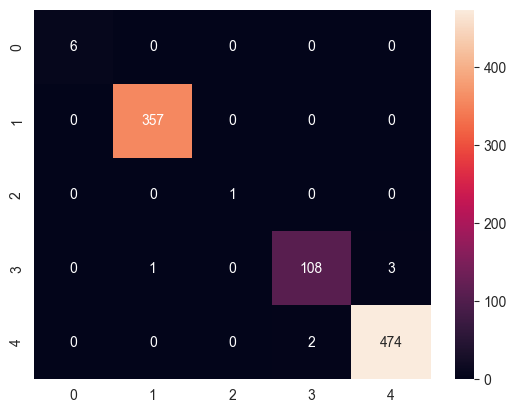

In [211]:
# confusion matrix
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d')

In [333]:
cbc = cb.CatBoostClassifier(task_type="GPU",
                            cat_features=cat_cols,
                            verbose=1,
                            random_seed=42)
cbc.fit(X, y)

Learning rate set to 0.089223
0:	learn: 1.4206776	total: 17.7ms	remaining: 17.7s
1:	learn: 1.1871498	total: 31.7ms	remaining: 15.8s
2:	learn: 1.0181012	total: 44.6ms	remaining: 14.8s
3:	learn: 0.8866192	total: 55.7ms	remaining: 13.9s
4:	learn: 0.7811567	total: 66.5ms	remaining: 13.2s
5:	learn: 0.6931447	total: 84ms	remaining: 13.9s
6:	learn: 0.6201694	total: 106ms	remaining: 15s
7:	learn: 0.5580977	total: 122ms	remaining: 15.1s
8:	learn: 0.5041810	total: 136ms	remaining: 15s
9:	learn: 0.4562614	total: 164ms	remaining: 16.2s
10:	learn: 0.4151281	total: 176ms	remaining: 15.8s
11:	learn: 0.3784907	total: 190ms	remaining: 15.7s
12:	learn: 0.3460962	total: 206ms	remaining: 15.6s
13:	learn: 0.3176709	total: 221ms	remaining: 15.6s
14:	learn: 0.2921522	total: 232ms	remaining: 15.2s
15:	learn: 0.2689807	total: 241ms	remaining: 14.8s
16:	learn: 0.2483915	total: 251ms	remaining: 14.5s
17:	learn: 0.2295710	total: 262ms	remaining: 14.3s
18:	learn: 0.2126769	total: 273ms	remaining: 14.1s
19:	learn: 

In [95]:
TARGET_MAP = {
    '["non-attack"]': 0,
    '["Defense Evasion"]': 1,
    '["Impact"]': 2,
    '["Initial Access"]': 3,
    '["Reconnaissance"]': 4,
    # '["Credential Access"]': 5,
}

In [212]:
counts = np.bincount(y.map(TARGET_MAP))
print(
    "Number of non-attack samples in training data: {} ({:.2f}% of total)".format(
        counts[0], 100 * float(counts[0]) / len(y)
    )
)

counts

NameError: name 'TARGET_MAP' is not defined

In [136]:
weight_for_0 = 1.0 / counts[0]
weight_for_1 = 1.0 / counts[1]
weight_for_2 = 1.0 / counts[2]
weight_for_3 = 1.0 / counts[3]
weight_for_4 = 1.0 / counts[4]

In [137]:
from tensorflow import keras
from keras.utils import to_categorical

model = keras.Sequential(
    [
        keras.layers.Dense(
            256, activation="relu", input_shape=(X_train.drop('timestamp', axis=1).shape[-1],)
        ),
        keras.layers.Dense(256, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(256, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(5, activation="softmax"),
    ]
)
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_24 (Dense)            (None, 256)               6912      
                                                                 
 dense_25 (Dense)            (None, 256)               65792     
                                                                 
 dropout_12 (Dropout)        (None, 256)               0         
                                                                 
 dense_26 (Dense)            (None, 256)               65792     
                                                                 
 dropout_13 (Dropout)        (None, 256)               0         
                                                                 
 dense_27 (Dense)            (None, 5)                 1285      
                                                                 
Total params: 139,781
Trainable params: 139,781
Non-tr

In [ ]:
def f1_score(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    return 2 * (precision * recall) / (precision + recall + K.epsilon())

metrics = [
    keras.metrics.FalseNegatives(name="fn"),
    keras.metrics.FalsePositives(name="fp"),
    keras.metrics.TrueNegatives(name="tn"),
    keras.metrics.TruePositives(name="tp"),
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
    f1_score,
]

model.compile(
    optimizer=keras.optimizers.Adam(1e-2), loss="categorical_crossentropy", metrics=metrics
)

callbacks = [keras.callbacks.ModelCheckpoint("fraud_model_at_epoch_{epoch}.h5")]
class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2, 3: weight_for_3, 4: weight_for_4}

model.fit(
    X_train.drop('timestamp', axis=1),
    to_categorical(y_train.map(TARGET_MAP)),
    batch_size=2048,
    epochs=30,
    verbose=2,
    callbacks=callbacks,
    validation_data=(X_val.drop('timestamp', axis=1), to_categorical(y_val.map(TARGET_MAP))),
    class_weight=class_weight,
)

In [ ]:
y_val_pred = model.predict(X_val.drop('timestamp', axis=1))
y_val_pred = np.argmax(y_val_pred, axis=1)
print(classification_report(y_val.map(TARGET_MAP), y_val_pred))

## Submission

In [334]:
ori_test_df = pd.read_csv(f"{DATA_DIR}/test.csv")
ori_test_df.head()

,id,timestamp,remote_addr,remote_user,hostname,time_local,request,status,body_bytes_sent,http_referer,...,request_time,upstream_connect_time,upstream_header_time,upstream_response_time,upstream_addr,upstream_status,connection,connection_requests,data.srcip,agent.ip
0,54481,"Sep 5, 2023 @ 00:26:44.850",10.26.152.242,-,vm-director-nginx,05/Sep/2023:07:26:43 +0700,GET /auth/resources/ofl9o/login/ub/ HTTP/2.0,404,118,-,...,0.002,0.000,0.001,0.001,10.45.184.154:32442,404,721725502,2,10.26.152.242,192.168.1.99
1,54482,"Sep 5, 2023 @ 00:26:44.880",202.80.215.96,-,vm-director-nginx,05/Sep/2023:07:26:44 +0700,GET /auth/resources/ofl9o/login/ub/ HTTP/2.0,404,118,-,...,0.002,0.001,0.003,0.003,10.45.184.148:32442,404,721725753,2,202.80.215.96,192.168.1.99
2,54483,"Sep 5, 2023 @ 00:26:46.898",36.85.73.24,-,vm-director-nginx,05/Sep/2023:07:26:44 +0700,GET /auth/resources/ofl9o/login/ub/ HTTP/2.0,404,118,-,...,0.003,0.001,0.002,0.002,10.45.184.148:32442,404,721725865,2,36.85.73.24,192.168.1.99
3,54484,"Sep 5, 2023 @ 00:26:46.945",180.248.23.157,-,vm-director-nginx,05/Sep/2023:07:26:46 +0700,GET /auth/resources/ofl9o/login/ub/ HTTP/2.0,404,118,-,...,0.002,0.000,0.002,0.002,10.45.184.148:32442,404,721725740,2,180.248.23.157,192.168.1.99
4,54485,"Sep 5, 2023 @ 00:26:48.856",182.1.80.255,-,vm-director-nginx,05/Sep/2023:07:26:46 +0700,GET /auth/resources/ofl9o/login/ub/ HTTP/2.0,404,118,-,...,0.001,0.000,0.001,0.001,10.45.184.154:32442,404,721726205,2,182.1.80.255,192.168.1.99


In [335]:
ori_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13599 entries, 0 to 13598
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      13599 non-null  int64  
 1   timestamp               13599 non-null  object 
 2   remote_addr             13599 non-null  object 
 3   remote_user             13599 non-null  object 
 4   hostname                13599 non-null  object 
 5   time_local              13599 non-null  object 
 6   request                 13599 non-null  object 
 7   status                  13599 non-null  int64  
 8   body_bytes_sent         13599 non-null  int64  
 9   http_referer            13599 non-null  object 
 10  http_user_agent         13599 non-null  object 
 11  http_x_forwarded_for    13599 non-null  object 
 12  time_iso8601            13599 non-null  object 
 13  request_method          13599 non-null  object 
 14  request_length          13599 non-null

In [336]:
train_df.status.value_counts()

404    2852
200    1777
403     112
303       8
400       4
302       4
301       1
Name: status, dtype: int64

In [337]:
ori_test_df.status.value_counts()

404    12722
200      656
400      152
422       25
502       22
500       11
504        6
416        2
403        1
405        1
407        1
Name: status, dtype: int64

In [338]:
test_df = ori_test_df.copy()
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'], format='%b %d, %Y @ %H:%M:%S.%f')
# test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])
test_df['upstream_connect_time'] = test_df['upstream_connect_time'].apply(clean_upstream_connect_time)
test_df['upstream_header_time'] = test_df['upstream_header_time'].apply(clean_upstream_connect_time)
test_df['upstream_response_time'] = test_df['upstream_response_time'].apply(clean_upstream_connect_time)
test_df['http_referer'] = test_df['http_referer'].apply(group_http_referer)
test_df['hour'] = test_df['timestamp'].dt.hour
test_df.drop([
    'id',
    # 'Unnamed: 0',
    'remote_addr',
    'remote_user',
    'hostname',
    'time_local',
    'request',
    # 'http_referer',
    'http_referer2',
    'http_x_forwarded_for',
    'http_user_agent',
    'time_iso8601',
    'upstream_addr',
    'upstream_status',
    # 'connection',
    'data.srcip',
    'agent.ip',
    # 'pairwise'
], axis=1, inplace=True)
test_df.head()

,timestamp,status,body_bytes_sent,http_referer,request_method,request_length,bytes_sent,request_time,upstream_connect_time,upstream_header_time,upstream_response_time,connection,connection_requests,hour
0,2023-09-05 00:26:44.850,404,118,-,GET,80,330,0.002,0.000,0.001,0.001,721725502,2,0
1,2023-09-05 00:26:44.880,404,118,-,GET,83,330,0.002,0.001,0.003,0.003,721725753,2,0
2,2023-09-05 00:26:46.898,404,118,-,GET,85,330,0.003,0.001,0.002,0.002,721725865,2,0
3,2023-09-05 00:26:46.945,404,118,-,GET,80,330,0.002,0.000,0.002,0.002,721725740,2,0
4,2023-09-05 00:26:48.856,404,118,-,GET,84,330,0.001,0.000,0.001,0.001,721726205,2,0


In [339]:
test_df.http_referer.value_counts()

-                12095
notrealdomain      901
realwebsite        480
localhost          123
Name: http_referer, dtype: int64

In [340]:
X_train.head()

,timestamp,status,body_bytes_sent,http_referer,request_method,request_length,bytes_sent,request_time,upstream_connect_time,upstream_header_time,upstream_response_time,connection,connection_requests,hour
2331,2023-09-04 23:59:59.079,200,29,localhost,POST,257,259,0.090,0.001,0.091,0.091,721508510,35,23
2025,2023-09-04 01:15:41.879,200,29,-,POST,254,259,0.096,0.001,0.095,0.095,714310185,15,1
39,2023-08-29 19:13:35.889,200,132,notrealdomain,POST,422,316,0.033,0.000,0.033,0.033,688421052,164,19
1829,2023-09-03 22:33:04.823,200,156,localhost,POST,254,387,0.137,0.000,0.133,0.133,713533956,23,22
4541,2023-08-30 22:53:09.831,404,118,-,GET,75,330,0.002,0.001,0.002,0.002,694883691,2,22


In [341]:
y_test_pred = cbc.predict(test_df)
y_test_pred

array([['["Reconnaissance"]'],
       ['["Reconnaissance"]'],
       ['["Reconnaissance"]'],
       ...,
       ['["Reconnaissance"]'],
       ['["Reconnaissance"]'],
       ['["Reconnaissance"]']], dtype=object)

In [342]:
y_test_pred[test_df[test_df.status != 404].index]

array([['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Reconnaissance"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Impact"]'],
       ['["Reconnaissance"]'],
       ['["Reconnaissance"]'],
       ['["Initial Access"]'],
       ['["Initial Access"]'],
       ['["Impact"]'],
       ['["Reconnaissance"]'],
       ['

In [343]:
test_df[test_df.status != 404].head(10)

,timestamp,status,body_bytes_sent,http_referer,request_method,request_length,bytes_sent,request_time,upstream_connect_time,upstream_header_time,upstream_response_time,connection,connection_requests,hour
43,2023-09-05 00:28:43.454,200,228,notrealdomain,POST,154,412,0.035,0.001,0.035,0.035,721742964,139,0
45,2023-09-05 00:28:45.237,200,2274,-,POST,620,2515,0.279,0.001,0.273,0.279,721742545,15,0
54,2023-09-05 00:28:35.301,200,102,-,POST,288,333,0.063,0.001,0.061,0.061,721742545,7,0
58,2023-09-05 00:28:13.486,200,5722,notrealdomain,POST,302,5931,0.139,0.000,0.137,0.138,721737354,174,0
78,2023-09-05 00:28:55.139,200,167,notrealdomain,POST,469,351,0.078,0.001,0.047,0.047,721742997,173,0
98,2023-09-05 00:29:07.108,400,78,-,POST,1380,473,0.005,0.001,0.006,0.006,721747503,1,0
113,2023-09-05 00:30:07.838,200,100,notrealdomain,POST,325,284,0.040,0.000,0.037,0.037,721755939,175,0
148,2023-09-05 00:30:19.748,200,27,notrealdomain,POST,270,210,0.159,0.000,0.088,0.088,721763354,45,0
150,2023-09-05 00:30:53.567,200,27,notrealdomain,POST,160,210,0.066,0.001,0.066,0.066,721749840,211,0
152,2023-09-05 00:30:55.409,200,166,notrealdomain,POST,470,350,0.093,0.001,0.038,0.038,721767373,185,0


In [344]:
submission_df = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")
submission_df['rule.mitre.tactic'] = y_test_pred
submission_df.head()

,id,rule.mitre.tactic
0,54481,"[""Reconnaissance""]"
1,54482,"[""Reconnaissance""]"
2,54483,"[""Reconnaissance""]"
3,54484,"[""Reconnaissance""]"
4,54485,"[""Reconnaissance""]"


In [345]:
y_train.value_counts()

["non-attack"]         1903
["Impact"]             1427
["Reconnaissance"]      449
["Defense Evasion"]      23
["Initial Access"]        3
Name: rule.mitre.tactic, dtype: int64

In [346]:
submission_df['rule.mitre.tactic'].value_counts()

["Reconnaissance"]     12648
["Impact"]               761
["Defense Evasion"]      178
["Initial Access"]        12
Name: rule.mitre.tactic, dtype: int64

In [135]:
submission_df.to_csv(f"{SUBMISSION_DIR}/submission1.csv", index=False)

## Post Evaluation

In [347]:
real_train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
real_train_df.shape

(54480, 28)

In [348]:
cross_tab = pd.crosstab(real_train_df['http_referer'], real_train_df['rule.mitre.tactic'])
# Filter rows where only the 'non attack' column has values greater than 0
cross_tab[(cross_tab['["non-attack"]'] > 0) & (cross_tab.drop(columns='["non-attack"]').eq(0).all(axis=1))]
# Filter rows where only the 'non attack' column has values greater than 0
non_attack_http = cross_tab[(cross_tab['["non-attack"]'] > 0) & (cross_tab.drop(columns='["non-attack"]').eq(0).all(axis=1))]
non_attack_http_list = non_attack_http.index.tolist()
non_attack_http_list

['binance.com',
 'http://175.45.184.147:80/actuator/gateway/routes',
 'http://175.45.184.193:80/',
 'http://175.45.184.30/b1a3k.php',
 'http://175.45.184.51/_phpMyAdmin/index.php?lang=en',
 'http://175.45.184.51/_phpmyadmin_/index.php?lang=en',
 'http://175.45.184.51/administrator/admin/index.php?lang=en',
 'http://175.45.184.51/administrator/phpmyadmin/index.php?lang=en',
 'http://175.45.184.51/database/index.php?lang=en',
 'http://175.45.184.51/db/db-admin/index.php?lang=en',
 'http://175.45.184.51/db/dbadmin/index.php?lang=en',
 'http://175.45.184.51/db/phpMyAdmin-4/index.php?lang=en',
 'http://175.45.184.51/dbadmin/index.php?lang=en',
 'http://175.45.184.51/myadmin/index.php?lang=en',
 'http://175.45.184.51/mysql-admin/index.php?lang=en',
 'http://175.45.184.51/mysql/admin/index.php?lang=en',
 'http://175.45.184.51/mysql/db/index.php?lang=en',
 'http://175.45.184.51/mysql/dbadmin/index.php?lang=en',
 'http://175.45.184.51/mysqladmin/index.php?lang=en',
 'http://175.45.184.51/phpMyA

In [349]:
ori_test_df[ori_test_df['http_referer'].isin(non_attack_http_list)]

,id,timestamp,remote_addr,remote_user,hostname,time_local,request,status,body_bytes_sent,http_referer,...,request_time,upstream_connect_time,upstream_header_time,upstream_response_time,upstream_addr,upstream_status,connection,connection_requests,data.srcip,agent.ip
257,54738,"Sep 5, 2023 @ 00:31:47.210",10.200.144.115,-,vm-director-nginx,05/Sep/2023:07:31:46 +0700,GET /assets/default/css/xtheme.css?cb6766e HTT...,404,281,https://halofilkom.notrealdomain.com/open.php,...,0.001,0.001,0.001,0.001,10.45.184.59:8001,404,721783562,3,10.200.144.115,192.168.1.99
521,55002,"Sep 5, 2023 @ 00:35:55.517",36.71.145.232,-,vm-director-nginx,05/Sep/2023:07:35:55 +0700,GET /assets/default/css/xtheme.css?cb6766e HTT...,404,281,https://halofilkom.notrealdomain.com/kb/faq.ph...,...,0.001,0.001,0.002,0.002,10.45.184.59:8001,404,721825599,3,36.71.145.232,192.168.1.99
1400,55881,"Sep 5, 2023 @ 00:55:12.999",10.200.160.31,-,vm-director-nginx,05/Sep/2023:07:55:12 +0700,GET /ujian.php?key=MzA7MTk7MDA7MDI7MTsyMDIzOzE...,404,36,https://siam.notrealdomain.com/exam.php,...,0.002,0.000,0.000,0.000,175.45.184.244:80,404,721970221,20,10.200.160.31,192.168.1.99
1419,55900,"Sep 5, 2023 @ 00:55:02.907",10.200.160.31,-,vm-director-nginx,05/Sep/2023:07:55:01 +0700,GET /ujian.php?key=MzA7MTk7MDA7MDI7MTsyMDIzOzE...,404,36,https://siam.notrealdomain.com/exam.php,...,0.002,0.000,0.001,0.001,175.45.184.244:80,404,721970221,19,10.200.160.31,192.168.1.99
1486,55967,"Sep 5, 2023 @ 00:57:00.966",10.34.3.151,-,vm-director-nginx,05/Sep/2023:07:57:00 +0700,GET /assets/default/css/xtheme.css?cb6766e HTT...,404,281,https://halofilkom.notrealdomain.com/,...,0.001,0.001,0.002,0.002,10.45.184.59:8001,404,721986851,2,10.34.3.151,192.168.1.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13201,67682,"Sep 6, 2023 @ 02:03:57.362",118.99.112.12,-,vm-director-nginx,06/Sep/2023:09:03:56 +0700,GET /kkn/kkn-kelompok-lokasi/undefined/undefin...,404,2425,https://mmd.notrealdomain.com/kkn/kkn-kelompok...,...,0.011,0.000,0.010,0.010,175.45.185.12:80,404,729170418,40,118.99.112.12,192.168.1.99
13438,67919,"Sep 6, 2023 @ 02:09:55.723",182.1.67.189,-,vm-director-nginx,06/Sep/2023:09:09:54 +0700,GET /kkn/kkn-kelompok-lokasi/undefined/undefin...,404,2421,https://mmd.notrealdomain.com/kkn/kkn-kelompok...,...,0.012,0.000,0.011,0.011,175.45.185.12:80,404,729216416,41,182.1.67.189,192.168.1.99
13483,67964,"Sep 6, 2023 @ 02:10:59.831",110.138.213.129,-,vm-director-nginx,06/Sep/2023:09:10:59 +0700,GET /kkn/kkn-kelompok-lokasi/undefined/undefin...,404,2424,https://mmd.notrealdomain.com/kkn/kkn-kelompok...,...,0.012,0.000,0.012,0.012,175.45.185.12:80,404,729237155,16,110.138.213.129,192.168.1.99
13493,67974,"Sep 6, 2023 @ 02:11:03.777",182.1.67.189,-,vm-director-nginx,06/Sep/2023:09:11:02 +0700,GET /kkn/kkn-kelompok-lokasi/undefined/undefin...,404,2423,https://mmd.notrealdomain.com/kkn/kkn-kelompok...,...,0.015,0.001,0.014,0.015,175.45.185.12:80,404,729216416,54,182.1.67.189,192.168.1.99


In [350]:
submission_df.loc[ori_test_df[ori_test_df['http_referer'].isin(non_attack_http_list)].index, 'rule.mitre.tactic'] = '["non-attack"]'
submission_df['rule.mitre.tactic'].value_counts()

["Reconnaissance"]     12600
["Impact"]               752
["Defense Evasion"]      172
["non-attack"]            63
["Initial Access"]        12
Name: rule.mitre.tactic, dtype: int64

In [323]:
submission_df.loc[ori_test_df[ori_test_df['http_referer'].isin(non_attack_http_list)].index, 'rule.mitre.tactic'].unique()

array(['["Impact"]', '["Reconnaissance"]'], dtype=object)

In [351]:
# Filter rows where only the 'non attack' column has values greater than 0
cross_tab[(cross_tab['["Impact"]'] > 0) & (cross_tab.drop(columns='["Impact"]').eq(0).all(axis=1))]
# Filter rows where only the 'non attack' column has values greater than 0
non_attack_http = cross_tab[(cross_tab['["Impact"]'] > 0) & (cross_tab.drop(columns='["Impact"]').eq(0).all(axis=1))]
non_attack_http_list = non_attack_http.index.tolist()
non_attack_http_list

['http://localhost/',
 'http://localhost/main',
 'http://localhost/main/home/course/14139/contents?course=param-4&isGuest=false',
 'http://localhost/main/home/dashboard',
 'http://localhost/main/home/mod_assign/14185/154349?module=param-5',
 'http://localhost/main/notifications/list',
 'https://mmd.notrealdomain.com/kkn/kkn-laporan-anggota-kelompok-lokasi/update?kkn_laporan_anggota_kelompok_lokasi=12422',
 'https://vlm2.notrealdomain.com/?redirect=0',
 'https://vlm2.notrealdomain.com/auth/saml2/sp/saml2-acs.php/vlm2.notrealdomain.com',
 'https://vlm2.notrealdomain.com/calendar/view.php?view=upcoming',
 'https://vlm2.notrealdomain.com/course/edit.php?id=14271',
 'https://vlm2.notrealdomain.com/course/index.php',
 'https://vlm2.notrealdomain.com/course/index.php?categoryid=12',
 'https://vlm2.notrealdomain.com/course/index.php?categoryid=134',
 'https://vlm2.notrealdomain.com/course/index.php?categoryid=19',
 'https://vlm2.notrealdomain.com/course/index.php?categoryid=2',
 'https://vlm2.

In [353]:
# Filter rows where only the 'non attack' column has values greater than 0
cross_tab[(cross_tab['["Credential Access"]'] > 0) & (cross_tab.drop(columns='["Credential Access"]').eq(0).all(axis=1))]
# Filter rows where only the 'non attack' column has values greater than 0
non_attack_http = cross_tab[(cross_tab['["Credential Access"]'] > 0) & (cross_tab.drop(columns='["Credential Access"]').eq(0).all(axis=1))]
non_attack_http_list = non_attack_http.index.tolist()

ori_test_df[ori_test_df['http_referer'].isin(non_attack_http_list)] = ["Credential Access"]


ValueError: Must have equal len keys and value when setting with an iterable

In [324]:
ori_test_df[ori_test_df['http_referer'].isin(non_attack_http_list)]

,id,timestamp,remote_addr,remote_user,hostname,time_local,request,status,body_bytes_sent,http_referer,...,request_time,upstream_connect_time,upstream_header_time,upstream_response_time,upstream_addr,upstream_status,connection,connection_requests,data.srcip,agent.ip
150,54631,"Sep 5, 2023 @ 00:30:53.567",118.99.127.60,-,vm-director-nginx,05/Sep/2023:07:30:51 +0700,POST /lib/ajax/service.php?sesskey=80PvzB2omy&...,200,27,https://vlm2.notrealdomain.com/course/view.php...,...,0.066,0.001,0.066,0.066,10.45.184.143:32401,200,721749840,211,118.99.127.60,192.168.1.99
183,54664,"Sep 5, 2023 @ 00:31:39.511",10.200.36.248,-,vm-director-nginx,05/Sep/2023:07:31:37 +0700,POST /lib/ajax/service.php?sesskey=q1rf91gNBa&...,200,27,https://vlm2.notrealdomain.com/course/view.php...,...,0.068,0.001,0.068,0.068,10.45.184.142:32401,200,721782233,38,10.200.36.248,192.168.1.99
191,54672,"Sep 5, 2023 @ 00:31:17.965",103.125.36.105,-,vm-director-nginx,05/Sep/2023:07:31:16 +0700,POST /lib/ajax/service.php?sesskey=IX8xb0qYse&...,200,27,https://vlm2.notrealdomain.com/course/view.php...,...,0.092,0.001,0.091,0.091,10.45.184.157:32401,200,721778460,44,103.125.36.105,192.168.1.99
251,54732,"Sep 5, 2023 @ 00:32:00.344",125.166.3.105,-,vm-director-nginx,05/Sep/2023:07:31:59 +0700,POST /lib/ajax/service.php?sesskey=W7rAmGuprG&...,200,27,https://vlm2.notrealdomain.com/course/view.php...,...,0.102,0.000,0.102,0.102,10.45.184.142:32401,200,721783630,160,125.166.3.105,192.168.1.99
415,54896,"Sep 5, 2023 @ 00:34:39.901",103.108.21.86,-,vm-director-nginx,05/Sep/2023:07:34:38 +0700,POST /lib/ajax/service.php?sesskey=RbTgUrIyYn&...,200,27,https://vlm2.notrealdomain.com/course/view.php...,...,0.074,0.000,0.074,0.074,10.45.184.157:32401,200,721813531,47,103.108.21.86,192.168.1.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13066,67547,"Sep 6, 2023 @ 02:01:11.400",125.160.205.201,-,vm-director-nginx,06/Sep/2023:09:01:10 +0700,POST /webservice/rest/server.php?moodlewsrestf...,200,2529,http://localhost/,...,0.202,0.000,0.197,0.201,10.45.184.142:32401,200,729160436,23,125.160.205.201,192.168.1.99
13432,67913,"Sep 6, 2023 @ 02:09:28.251",139.195.158.98,-,vm-director-nginx,06/Sep/2023:09:09:27 +0700,POST /webservice/rest/server.php?moodlewsrestf...,200,840,http://localhost/,...,0.096,0.000,0.095,0.095,10.45.184.157:32401,200,729223396,24,139.195.158.98,192.168.1.99
13484,67965,"Sep 6, 2023 @ 02:11:00.079",140.213.58.119,-,vm-director-nginx,06/Sep/2023:09:10:58 +0700,POST /lib/ajax/service.php?sesskey=kWel037nbW&...,200,27,https://vlm2.notrealdomain.com/course/view.php...,...,0.085,0.001,0.085,0.085,10.45.184.143:32401,200,729236960,224,140.213.58.119,192.168.1.99
13497,67978,"Sep 6, 2023 @ 02:11:05.954",10.200.194.240,-,vm-director-nginx,06/Sep/2023:09:11:03 +0700,POST /lib/ajax/service.php?sesskey=waMhFqbFh0&...,200,27,https://vlm2.notrealdomain.com/course/view.php...,...,0.082,0.001,0.082,0.082,10.45.184.142:32401,200,729238167,203,10.200.194.240,192.168.1.99


In [354]:
test_df[test_df['request_method'].isin(["HEAD"])]

,timestamp,status,body_bytes_sent,http_referer,request_method,request_length,bytes_sent,request_time,upstream_connect_time,upstream_header_time,upstream_response_time,connection,connection_requests,hour
192,2023-09-05 00:31:19.288,404,0,-,HEAD,120,154,0.002,0.001,0.002,0.002,721779079,1,0
6027,2023-09-05 22:34:53.144,404,0,-,HEAD,120,154,0.002,0.000,0.001,0.001,728024745,1,22
8725,2023-09-06 00:21:34.290,404,0,-,HEAD,120,154,0.001,0.000,0.001,0.001,728392396,1,0


In [355]:
submission_df.loc[test_df[test_df['request_method'].isin(["HEAD"])].index, "rule.mitre.tactic"] = '["non-attack"]'
submission_df['rule.mitre.tactic'].value_counts()
# test_df[test_df['remote_user'].isin(["GapuraUb2020-Mobile", "google-oauth-client"])] = ["non-attack"]

["Reconnaissance"]     12597
["Impact"]               752
["Defense Evasion"]      172
["non-attack"]            66
["Initial Access"]        12
Name: rule.mitre.tactic, dtype: int64

In [356]:
ori_test_df[ori_test_df['remote_user'].isin(["GapuraUb2020-Mobile", "google-oauth-client"])]

,id,timestamp,remote_addr,remote_user,hostname,time_local,request,status,body_bytes_sent,http_referer,...,request_time,upstream_connect_time,upstream_header_time,upstream_response_time,upstream_addr,upstream_status,connection,connection_requests,data.srcip,agent.ip
98,54579,"Sep 5, 2023 @ 00:29:07.108",10.200.192.31,GapuraUb2020-Mobile,vm-director-nginx,05/Sep/2023:07:29:06 +0700,POST /auth/realms/ub/protocol/openid-connect/t...,400,78,-,...,0.005,0.001,0.006,0.006,10.45.184.148:32442,400,721747503,1,10.200.192.31,192.168.1.99
286,54767,"Sep 5, 2023 @ 00:31:53.266",36.71.75.102,GapuraUb2020-Mobile,vm-director-nginx,05/Sep/2023:07:31:51 +0700,POST /auth/realms/ub/protocol/openid-connect/t...,400,78,-,...,0.006,0.000,0.005,0.005,10.45.184.154:32442,400,721784794,1,36.71.75.102,192.168.1.99
410,54891,"Sep 5, 2023 @ 00:34:05.377",10.26.69.195,GapuraUb2020-Mobile,vm-director-nginx,05/Sep/2023:07:34:03 +0700,POST /auth/realms/ub/protocol/openid-connect/t...,400,78,-,...,0.008,0.001,0.007,0.007,10.45.184.154:32442,400,721808264,2,10.26.69.195,192.168.1.99
664,55145,"Sep 5, 2023 @ 00:39:03.720",10.200.113.147,GapuraUb2020-Mobile,vm-director-nginx,05/Sep/2023:07:39:03 +0700,POST /auth/realms/ub/protocol/openid-connect/t...,400,78,-,...,0.005,0.001,0.006,0.006,10.45.184.148:32442,400,721855930,1,10.200.113.147,192.168.1.99
800,55281,"Sep 5, 2023 @ 00:42:23.955",202.67.46.249,GapuraUb2020-Mobile,vm-director-nginx,05/Sep/2023:07:42:22 +0700,POST /auth/realms/ub/protocol/openid-connect/t...,400,78,-,...,0.005,0.000,0.004,0.004,10.45.184.154:32442,400,721882515,1,202.67.46.249,192.168.1.99
2510,56991,"Sep 5, 2023 @ 01:26:16.959",180.248.23.102,GapuraUb2020-Mobile,vm-director-nginx,05/Sep/2023:08:26:16 +0700,POST /auth/realms/ub/protocol/openid-connect/t...,400,78,-,...,0.007,0.000,0.006,0.006,10.45.184.148:32442,400,722190027,1,180.248.23.102,192.168.1.99
2732,57213,"Sep 5, 2023 @ 01:32:33.376",103.172.204.154,GapuraUb2020-Mobile,vm-director-nginx,05/Sep/2023:08:32:31 +0700,POST /auth/realms/ub/protocol/openid-connect/t...,400,84,-,...,0.014,0.000,0.009,0.009,10.45.184.148:32442,400,722229872,1,103.172.204.154,192.168.1.99
2998,57479,"Sep 5, 2023 @ 01:38:55.797",182.4.132.95,GapuraUb2020-Mobile,vm-director-nginx,05/Sep/2023:08:38:54 +0700,POST /auth/realms/ub/protocol/openid-connect/t...,400,78,-,...,0.007,0.000,0.006,0.006,10.45.184.154:32442,400,722281284,1,182.4.132.95,192.168.1.99
3095,57576,"Sep 5, 2023 @ 01:41:25.935",182.4.132.224,GapuraUb2020-Mobile,vm-director-nginx,05/Sep/2023:08:41:24 +0700,POST /auth/realms/ub/protocol/openid-connect/t...,400,78,-,...,0.025,0.000,0.004,0.004,10.45.184.148:32442,400,722300601,1,182.4.132.224,192.168.1.99
3133,57614,"Sep 5, 2023 @ 01:42:14.038",114.5.220.173,GapuraUb2020-Mobile,vm-director-nginx,05/Sep/2023:08:42:13 +0700,POST /auth/realms/ub/protocol/openid-connect/t...,400,78,-,...,0.005,0.000,0.004,0.004,10.45.184.154:32442,400,722308096,1,114.5.220.173,192.168.1.99


In [357]:
submission_df.loc[ori_test_df[ori_test_df['remote_user'].isin(["GapuraUb2020-Mobile", "google-oauth-client"])].index, "rule.mitre.tactic"] = '["non-attack"]'
submission_df['rule.mitre.tactic'].value_counts()

["Reconnaissance"]     12594
["Impact"]               722
["Defense Evasion"]      172
["non-attack"]            99
["Initial Access"]        12
Name: rule.mitre.tactic, dtype: int64

In [358]:
test_df[test_df['status'] > 404]

,timestamp,status,body_bytes_sent,http_referer,request_method,request_length,bytes_sent,request_time,upstream_connect_time,upstream_header_time,upstream_response_time,connection,connection_requests,hour
439,2023-09-05 00:34:23.449,500,8173,-,GET,58,8435,0.007,0.001,0.008,0.008,721803465,246,0
492,2023-09-05 00:35:39.439,502,157,-,GET,193,375,0.001,0.000,0.000,0.001,721823024,1,0
1540,2023-09-05 00:59:09.095,422,6308,notrealdomain,GET,1297,6564,0.018,0.001,0.019,0.019,721998353,1,0
1747,2023-09-05 01:05:33.558,500,8546,-,GET,90,9007,0.038,0.001,0.010,0.038,722037706,2,1
1790,2023-09-05 01:07:05.621,500,8557,-,GET,65,9019,0.031,0.001,0.011,0.032,722046159,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11117,2023-09-06 01:14:53.896,422,8538,notrealdomain,GET,113,8808,0.018,0.001,0.017,0.019,728826693,55,1
11417,2023-09-06 01:23:00.424,502,157,-,GET,254,380,0.001,0.000,0.000,0.001,728917707,1,1
12135,2023-09-06 01:38:31.707,407,30045,-,GET,560,30439,0.217,0.000,0.216,0.217,729020429,1,1
13028,2023-09-06 02:00:25.047,416,406,realwebsite,GET,803,610,0.002,0.000,0.001,0.001,729156920,1,2


In [359]:
submission_df.loc[test_df[test_df['status'] > 404].index, 'rule.mitre.tactic'] = '["non-attack"]'
submission_df['rule.mitre.tactic'].value_counts()

["Reconnaissance"]     12546
["Impact"]               719
["Defense Evasion"]      170
["non-attack"]           152
["Initial Access"]        12
Name: rule.mitre.tactic, dtype: int64

In [360]:
submission_df.loc[test_df[test_df['status'] == 200].index, 'rule.mitre.tactic']

43       ["Impact"]
45       ["Impact"]
54       ["Impact"]
58       ["Impact"]
78       ["Impact"]
            ...    
13556    ["Impact"]
13564    ["Impact"]
13587    ["Impact"]
13588    ["Impact"]
13589    ["Impact"]
Name: rule.mitre.tactic, Length: 656, dtype: object

In [361]:
cross_tab = pd.crosstab(real_train_df['upstream_addr'], real_train_df['rule.mitre.tactic'])
cross_tab[(cross_tab['["non-attack"]'] > 0) & (cross_tab.drop(columns='["non-attack"]').eq(0).all(axis=1))]
upstream_addr_nonattack = cross_tab[(cross_tab['["non-attack"]'] > 0) & (cross_tab.drop(columns='["non-attack"]').eq(0).all(axis=1))]
upstream_addr_list = upstream_addr_nonattack.index.tolist()
upstream_addr_list

['10.45.184.134:31168, 10.45.184.135:31168, 10.45.184.136:31168 502, 502,',
 '10.45.184.136:31168, 10.45.184.135:31168, 10.45.184.134:31168 502, 502,',
 '10.45.184.142:31852',
 '10.45.184.142:32401, 10.45.184.157:32401, 10.45.184.143:32401 502, 502,',
 '10.45.184.143:31852',
 '10.45.184.143:32401, 10.45.184.157:32401, 10.45.184.142:32401 502, 502,',
 '10.45.184.148:32442, 10.45.184.154:32442 500,',
 '10.45.184.154:32442, 10.45.184.148:32442 502,',
 '10.45.184.157:31852',
 '10.45.184.157:32401, 10.45.184.143:32401, 10.45.184.142:32401 502, 502,',
 '10.45.188.254:44453',
 '175.45.184.137:80',
 '175.45.184.173:80',
 '175.45.184.237:80',
 '175.45.184.241:80',
 '175.45.184.242:80',
 '175.45.184.243:80',
 '175.45.184.39:80',
 '175.45.185.33:84']

In [362]:
ori_test_df[ori_test_df['upstream_addr'].isin(upstream_addr_list)]

,id,timestamp,remote_addr,remote_user,hostname,time_local,request,status,body_bytes_sent,http_referer,...,request_time,upstream_connect_time,upstream_header_time,upstream_response_time,upstream_addr,upstream_status,connection,connection_requests,data.srcip,agent.ip
492,54973,"Sep 5, 2023 @ 00:35:39.439",104.234.204.134,-,vm-director-nginx,05/Sep/2023:07:35:39 +0700,GET /.env HTTP/1.1,502,157,-,...,0.001,"-, -, -","-, -, -","0.000, 0.001, 0.000","10.45.184.134:31168, 10.45.184.135:31168, 10.4...",502,721823024,1,104.234.204.134,192.168.1.99
3905,58386,"Sep 5, 2023 @ 02:01:47.428",10.30.16.201,-,vm-director-nginx,05/Sep/2023:09:01:45 +0700,GET /ujian.php?key=MDE7MTA7MDM7MTAzOzE7MjAyMzs...,404,36,https://siam.notrealdomain.com/exam.php,...,0.002,0.000,0.001,0.001,175.45.184.243:80,404,722469919,18,10.30.16.201,192.168.1.99
4379,58860,"Sep 5, 2023 @ 17:41:15.380",60.13.7.94,-,vm-director-nginx,06/Sep/2023:00:41:13 +0700,GET / HTTP/1.0,502,157,-,...,0.001,"-, -, -","-, -, -","0.000, 0.000, 0.001","10.45.184.136:31168, 10.45.184.135:31168, 10.4...",502,727824873,1,60.13.7.94,192.168.1.99
4390,58871,"Sep 5, 2023 @ 17:41:41.403",59.52.101.200,-,vm-director-nginx,06/Sep/2023:00:41:40 +0700,GET / HTTP/1.1,502,559,-,...,0.001,"-, -, -","-, -, -","0.000, 0.000, 0.000","10.45.184.134:31168, 10.45.184.135:31168, 10.4...",502,727825291,1,59.52.101.200,192.168.1.99
4492,58973,"Sep 5, 2023 @ 19:37:05.188",101.44.80.137,-,vm-director-nginx,06/Sep/2023:02:37:04 +0700,GET /wp-app/pendaftaran/smub/wp-login.php HTTP...,502,559,-,...,0.001,-,-,0.001,175.45.184.173:80,502,727909653,1,101.44.80.137,192.168.1.99
4566,59047,"Sep 5, 2023 @ 18:00:00.768",36.99.136.128,-,vm-director-nginx,06/Sep/2023:00:59:58 +0700,GET / HTTP/1.1,502,559,-,...,1.934,-,-,1.935,175.45.184.39:80,502,727846465,1,36.99.136.128,192.168.1.99
4567,59048,"Sep 5, 2023 @ 18:00:02.661",36.99.136.129,-,vm-director-nginx,06/Sep/2023:01:00:01 +0700,GET / HTTP/1.1,502,559,-,...,2.641,-,-,2.642,175.45.184.39:80,502,727846491,1,36.99.136.129,192.168.1.99
4575,59056,"Sep 5, 2023 @ 18:00:10.666",36.99.136.128,-,vm-director-nginx,06/Sep/2023:01:00:10 +0700,GET / HTTP/1.1,502,559,-,...,3.006,-,-,3.006,175.45.184.39:80,502,727846724,1,36.99.136.128,192.168.1.99
4577,59058,"Sep 5, 2023 @ 17:59:52.722",36.99.136.129,-,vm-director-nginx,06/Sep/2023:00:59:50 +0700,GET / HTTP/1.1,502,559,-,...,3.007,-,-,3.006,175.45.184.39:80,502,727846250,1,36.99.136.129,192.168.1.99
4694,59175,"Sep 5, 2023 @ 19:08:41.280",52.70.240.171,-,vm-director-nginx,06/Sep/2023:02:08:40 +0700,GET /wp-app/pendaftaran/profesi/ HTTP/1.1,502,157,-,...,0.001,-,-,0.000,175.45.184.173:80,502,727895877,1,52.70.240.171,192.168.1.99


In [363]:
submission_df.loc[ori_test_df[ori_test_df['upstream_addr'].isin(upstream_addr_list)].index, 'rule.mitre.tactic'] = '["non-attack"]'
submission_df['rule.mitre.tactic'].value_counts()

["Reconnaissance"]     12533
["Impact"]               719
["Defense Evasion"]      169
["non-attack"]           166
["Initial Access"]        12
Name: rule.mitre.tactic, dtype: int64

In [364]:
submission_df.to_csv(f"{SUBMISSION_DIR}/submission2(post-eval).csv", index=False)

In [365]:
y_test_pred_proba = cbc.predict_proba(test_df)
y_test_pred_proba

array([[1.99949880e-04, 6.20256420e-03, 4.77730467e-04, 3.68824746e-04,
        9.87814299e-01, 4.93663145e-03],
       [2.32148012e-04, 2.86356480e-03, 8.61732946e-04, 4.39483854e-04,
        9.89123944e-01, 6.47912599e-03],
       [2.20053618e-04, 3.81021656e-03, 7.69349144e-04, 4.27164656e-04,
        9.86527288e-01, 8.24592812e-03],
       ...,
       [3.67118326e-05, 4.55139289e-04, 1.07670763e-04, 5.58767479e-05,
        9.98326958e-01, 1.01764360e-03],
       [3.67118326e-05, 4.55139289e-04, 1.07670763e-04, 5.58767479e-05,
        9.98326958e-01, 1.01764360e-03],
       [5.21759567e-05, 1.30409833e-03, 9.79448558e-05, 7.73795843e-05,
        9.97757433e-01, 7.10968576e-04]])

In [366]:
# filter only where the probability of ["Reconnaissance"] is lower than 0.9
y_test_pred_proba[y_test_pred_proba[:, 3] > 0.99]

array([], shape=(0, 6), dtype=float64)

In [367]:
noattack_df = pd.read_csv(f"{DATA_DIR}/noattack.csv")
noattack_df.head()

,Unnamed: 0,id,rule.mitre.tactic
0,0,54481,non-attack
1,1,54482,non-attack
2,2,54483,non-attack
3,3,54484,non-attack
4,4,54485,non-attack


In [368]:
noattack_df['rule.mitre.tactic'].value_counts()

non-attack        9309
Reconnaissance    4290
Name: rule.mitre.tactic, dtype: int64

In [369]:
noattack_df['rule.mitre.tactic'] = '["' + noattack_df['rule.mitre.tactic'] + '"]'
noattack_df['rule.mitre.tactic'].value_counts()

["non-attack"]        9309
["Reconnaissance"]    4290
Name: rule.mitre.tactic, dtype: int64

In [370]:
timpa_index = submission_df.loc[submission_df['rule.mitre.tactic'] == '["Reconnaissance"]', 'rule.mitre.tactic'].index
timpa_index

Int64Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,
                9,
            ...
            13586, 13590, 13591, 13592, 13593, 13594, 13595, 13596, 13597,
            13598],
           dtype='int64', length=12533)

In [371]:
submission_df.loc[timpa_index, 'rule.mitre.tactic'] = noattack_df.loc[timpa_index, 'rule.mitre.tactic']
submission_df['rule.mitre.tactic'].value_counts()

["non-attack"]         8723
["Reconnaissance"]     3976
["Impact"]              719
["Defense Evasion"]     169
["Initial Access"]       12
Name: rule.mitre.tactic, dtype: int64

In [372]:
# submission_df.to_csv(f"{SUBMISSION_DIR}/submission3(post-timpa).csv", index=False)
submission_df.to_csv(f"{SUBMISSION_DIR}/submission5(post-timpa).csv", index=False)

In [309]:
submission_df = pd.read_csv(f"{SUBMISSION_DIR}/submission3(post-timpa).csv")

In [300]:
y_test_pred_proba[y_test_pred_proba[:, 3] > 0.99]

array([[2.00361638e-03, 4.84190867e-04, 2.21065298e-04, 9.95355178e-01,
        1.93594978e-03],
       [2.15402558e-03, 3.26796070e-04, 1.86753248e-04, 9.95447197e-01,
        1.88522797e-03],
       [3.48512542e-03, 3.30337800e-04, 2.33641320e-04, 9.94154097e-01,
        1.79679868e-03],
       ...,
       [3.60405179e-04, 8.92808586e-05, 4.33054534e-05, 9.98936536e-01,
        5.70472863e-04],
       [3.60405179e-04, 8.92808586e-05, 4.33054534e-05, 9.98936536e-01,
        5.70472863e-04],
       [2.50148783e-03, 1.19387115e-04, 9.13824602e-05, 9.96554099e-01,
        7.33643577e-04]])

In [302]:
y_test_pred_proba

array([[1.06557452e-02, 4.61594866e-04, 3.69633609e-04, 9.85649653e-01,
        2.86337293e-03],
       [2.00361638e-03, 4.84190867e-04, 2.21065298e-04, 9.95355178e-01,
        1.93594978e-03],
       [3.37817047e-03, 7.84823575e-04, 4.13739226e-04, 9.89642285e-01,
        5.78098218e-03],
       ...,
       [3.60405179e-04, 8.92808586e-05, 4.33054534e-05, 9.98936536e-01,
        5.70472863e-04],
       [3.60405179e-04, 8.92808586e-05, 4.33054534e-05, 9.98936536e-01,
        5.70472863e-04],
       [2.50148783e-03, 1.19387115e-04, 9.13824602e-05, 9.96554099e-01,
        7.33643577e-04]])

In [305]:
y_test_pred_proba[:, 3]

array([0.98564965, 0.99535518, 0.98964228, ..., 0.99893654, 0.99893654,
       0.9965541 ])

In [311]:
submission_df["proba_recon"] = y_test_pred_proba[:, 3]
submission_df.head()

,id,rule.mitre.tactic,proba_recon
0,54481,"[""non-attack""]",0.985650
1,54482,"[""non-attack""]",0.995355
2,54483,"[""non-attack""]",0.989642
3,54484,"[""non-attack""]",0.988319
4,54485,"[""non-attack""]",0.954976


In [312]:
submission_df.loc[submission_df['proba_recon'] > 0.995, 'rule.mitre.tactic'] = '["Reconnaissance"]'
submission_df['rule.mitre.tactic'].value_counts()

["Reconnaissance"]     9117
["non-attack"]         3448
["Impact"]              746
["Defense Evasion"]     284
["Initial Access"]        4
Name: rule.mitre.tactic, dtype: int64

In [314]:
submission_df.drop('proba_recon', axis=1, inplace=True)

In [315]:
submission_df.to_csv(f"{SUBMISSION_DIR}/submission4(post-proba).csv", index=False)